In [1]:
import os
import shutil
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

# Define the root directory and paths for the combined dataset
data_path = 'C:/Users/swani/OneDrive/Desktop/Deep_learning/project/chest_xray'
combined_path = 'C:/Users/swani/OneDrive/Desktop/Deep_learning/project/chest_xray_total'

# Create a combined dataset directory
os.makedirs(combined_path, exist_ok=True)

# Combine all images from train, val, and test into a single directory for each class
for split in ['train', 'val', 'test']:
    for class_name in ['normal', 'pneumonia']:
        source_dir = os.path.join(data_path, split, class_name)
        target_dir = os.path.join(combined_path, class_name)
        os.makedirs(target_dir, exist_ok=True)
        for file_name in os.listdir(source_dir):
            source_file = os.path.join(source_dir, file_name)
            target_file = os.path.join(target_dir, file_name)
            shutil.copyfile(source_file, target_file)

In [2]:
import torch
import numpy as np
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Subset  # Imported Subset
from sklearn.model_selection import train_test_split  # Imported train_test_split

# Define transformations
transform = transforms.Compose([
    transforms.Grayscale(),  # Convert images to grayscale if not already
    transforms.RandomResizedCrop(size=256, scale=(0.8, 1.0)),
    transforms.RandomRotation(degrees=15),
    transforms.RandomHorizontalFlip(),
    transforms.CenterCrop(size=224),
    transforms.ToTensor(),  # Convert images to PyTorch tensors
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize the images
])

# Load the combined dataset
combined_dataset = datasets.ImageFolder(combined_path, transform=transform)

# Calculate split sizes
total_size = len(combined_dataset)
train_size = int(0.7 * total_size)
valid_size = int(0.15 * total_size)
test_size = total_size - train_size - valid_size

# Split the combined dataset
indices = list(range(total_size))
np.random.seed(25)  # Ensure reproducibility
np.random.shuffle(indices)

train_indices = indices[:train_size]
valid_indices = indices[train_size:train_size + valid_size]
test_indices = indices[train_size + valid_size:]

# Create subset datasets
train_dataset = Subset(combined_dataset, train_indices)
val_dataset = Subset(combined_dataset, valid_indices)
test_dataset = Subset(combined_dataset, test_indices)

# Create data loaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# Print dataset sizes
print(f'Total samples: {total_size}')
print(f'Train samples: {train_size}')
print(f'Validation samples: {valid_size}')
print(f'Test samples: {test_size}')


Total samples: 5856
Train samples: 4099
Validation samples: 878
Test samples: 879


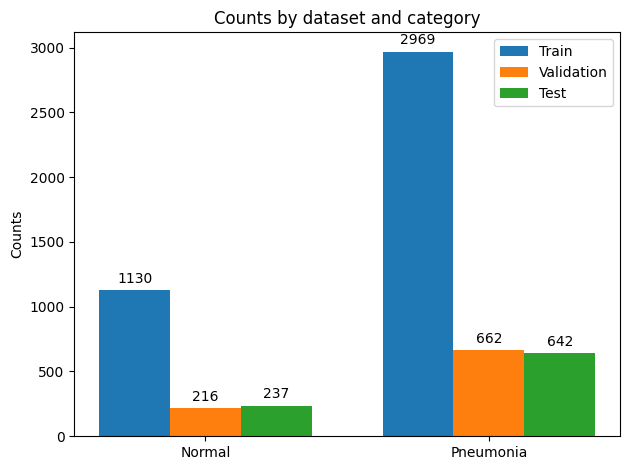

In [3]:
import matplotlib.pyplot as plt

def count_labels(dataloader):
    label_count = {'Normal': 0, 'Pneumonia': 0}
    for images, labels in dataloader:
        for label in labels:
            if label == 0:  # Assuming '0' is the label for 'Normal'
                label_count['Normal'] += 1
            else:  # Assuming '1' is the label for 'Pneumonia'
                label_count['Pneumonia'] += 1
    return label_count

# Assuming train_loader, valid_loader, and test_loader are already defined
train_counts = count_labels(train_loader)
valid_counts = count_labels(val_loader)
test_counts = count_labels(test_loader)

# Data to plot
labels = ['Normal', 'Pneumonia']
train_data = [train_counts['Normal'], train_counts['Pneumonia']]
valid_data = [valid_counts['Normal'], valid_counts['Pneumonia']]
test_data = [test_counts['Normal'], test_counts['Pneumonia']]

x = range(len(labels))  # the label locations
width = 0.25  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x, train_data, width, label='Train')
rects2 = ax.bar([p + width for p in x], valid_data, width, label='Validation')
rects3 = ax.bar([p + width * 2 for p in x], test_data, width, label='Test')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Counts')
ax.set_title('Counts by dataset and category')
ax.set_xticks([p + width for p in x])
ax.set_xticklabels(labels)
ax.legend()

# Function to attach a text label above each bar
def autolabel(rects):
    """Attach a text label above each bar in rects, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()

plt.show()

Train Set:


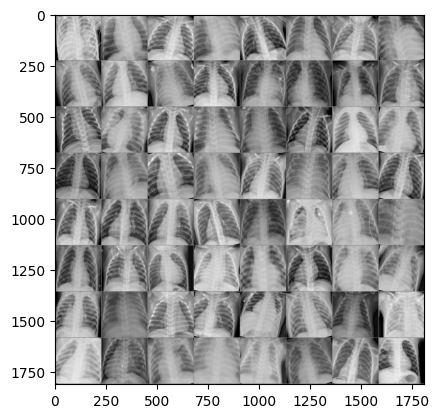

pneumonia pneumonia normal pneumonia normal pneumonia normal pneumonia pneumonia pneumonia pneumonia normal pneumonia pneumonia pneumonia pneumonia normal pneumonia normal pneumonia pneumonia normal pneumonia pneumonia normal pneumonia pneumonia pneumonia normal pneumonia pneumonia normal normal pneumonia pneumonia normal pneumonia pneumonia pneumonia pneumonia pneumonia normal pneumonia pneumonia pneumonia normal pneumonia pneumonia pneumonia pneumonia normal pneumonia pneumonia normal pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia normal pneumonia
Validation Set:


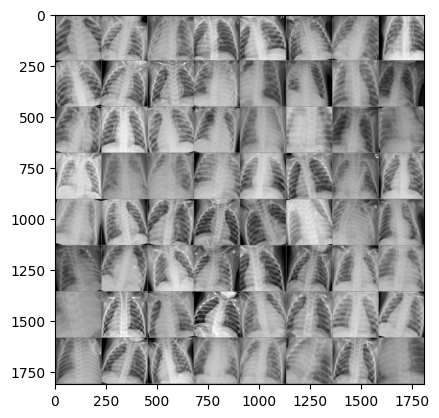

pneumonia normal pneumonia normal pneumonia pneumonia pneumonia pneumonia pneumonia normal normal pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia normal pneumonia pneumonia pneumonia pneumonia pneumonia normal pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia normal pneumonia pneumonia normal pneumonia pneumonia pneumonia normal pneumonia normal pneumonia pneumonia pneumonia normal pneumonia normal pneumonia pneumonia pneumonia pneumonia normal pneumonia
Test Set:


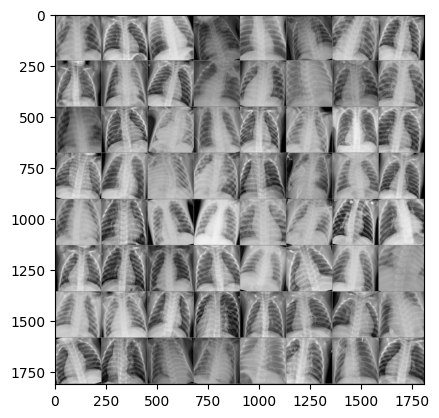

pneumonia normal pneumonia pneumonia pneumonia pneumonia pneumonia normal normal pneumonia normal pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia normal pneumonia pneumonia normal pneumonia normal normal normal pneumonia pneumonia pneumonia normal pneumonia pneumonia normal pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia normal normal normal normal pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia normal normal pneumonia pneumonia normal pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia normal


In [4]:
import torchvision as torchvision
import numpy as np
import matplotlib.pyplot as plt
import torchvision.utils

# Function to show images
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Function to print and visualize data loader
def print_data_loader(data_loader, dataset_name):
    print(f'{dataset_name} Set:')
    dataiter = iter(data_loader)
    images, labels = next(dataiter)
    # Show images
    imshow(torchvision.utils.make_grid(images))
    # Print labels
    print(' '.join(f'{combined_dataset.classes[labels[j]]}' for j in range(len(labels))))

# Visualize the train loader
print_data_loader(train_loader, 'Train')

# Visualize the validation loader
print_data_loader(val_loader, 'Validation')

# Visualize the test loader
print_data_loader(test_loader, 'Test')


In [9]:
import torch
import torch.nn as nn  # Import torch.nn module
import torch.optim as optim
import numpy as np
import torchvision.transforms as transforms
import torchvision.datasets as datasets

class STNModel(nn.Module):
    def __init__(self):
        super(STNModel, self).__init__()

        # Localization network: Convolutional layers followed by FC layers
        self.localization = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=7),
            nn.MaxPool2d(2, stride=2),
            nn.ReLU(True),
            nn.Conv2d(8, 10, kernel_size=5),
            nn.MaxPool2d(2, stride=2),
            nn.ReLU(True)
        )

        # Regressor for the 3 * 2 affine matrix
        self.fc_loc = nn.Sequential(
            nn.Linear(10 * 53 * 53, 32),
            nn.ReLU(True),
            nn.Linear(32, 3 * 2)
        )

        # Initialize the weights/bias with identity transformation
        self.fc_loc[2].weight.data.zero_()
        self.fc_loc[2].bias.data.copy_(torch.tensor([1, 0, 0, 0, 1, 0], dtype=torch.float))

        # Classification network: ResNet18 with modified final layer
        self.resnet = model.resnet18(pretrained=True)
        num_ftrs = self.resnet.fc.in_features
        self.resnet.fc = nn.Linear(num_ftrs, len(classes))

    def forward(self, x):
        # Spatial transformer localization-network forward function
        xs = self.localization(x)
        xs = xs.view(-1, 10 * 53 * 53)
        theta = self.fc_loc(xs)
        theta = theta.view(-1, 2, 3)

        # Grid generator and sampler
        grid = nn.functional.affine_grid(theta, x.size())
        x = nn.functional.grid_sample(x, grid)

        # Classification network forward function
        x = self.resnet(x)
        return x



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = STNModel().to(device)

AttributeError: 'Net' object has no attribute 'resnet18'

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
import time
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Training loop
num_epochs = 10
train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []

start_time = time.time()
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        print('Started Training')
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct_train / total_train
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    model.eval()
    validation_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            validation_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss = validation_loss / len(val_loader)
    val_accuracy = 100 * correct_val / total_val
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f'Epoch [{epoch + 1}/{num_epochs}] Training Loss: {train_loss:.4f}, Training Accuracy: {train_accuracy:.2f}%')
    print(f'Epoch [{epoch + 1}/{num_epochs}] Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%')

print('Finished Training')
elapsed_time = time.time() - start_time
print(f'Training time: {elapsed_time:.2f} seconds')

Started Training


RuntimeError: shape '[-1, 90]' is invalid for input of size 1730560